In [1]:
using Sunny, GLMakie

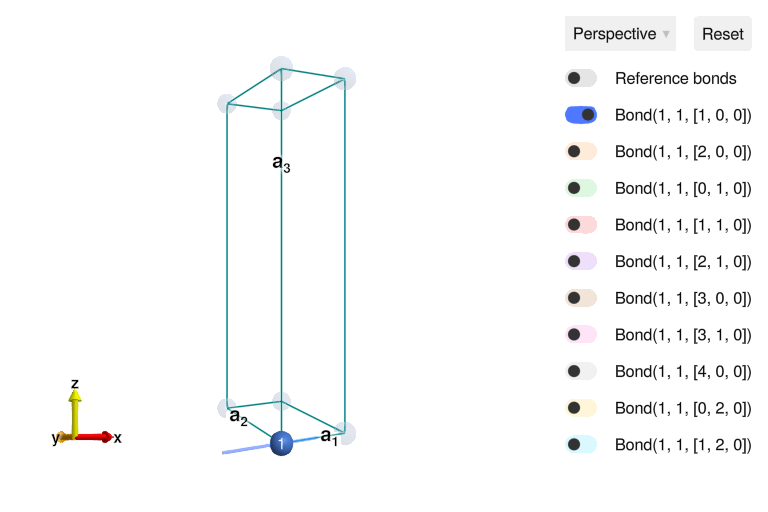

In [2]:
a = 5 # (Å)
latvecs = lattice_vectors(a, 2a, 5a, 90, 90, 90) 
positions = [[0 0 0]] #put atoms of the vertices of this lattice
cryst = Crystal(latvecs, positions; )
view_crystal(cryst)

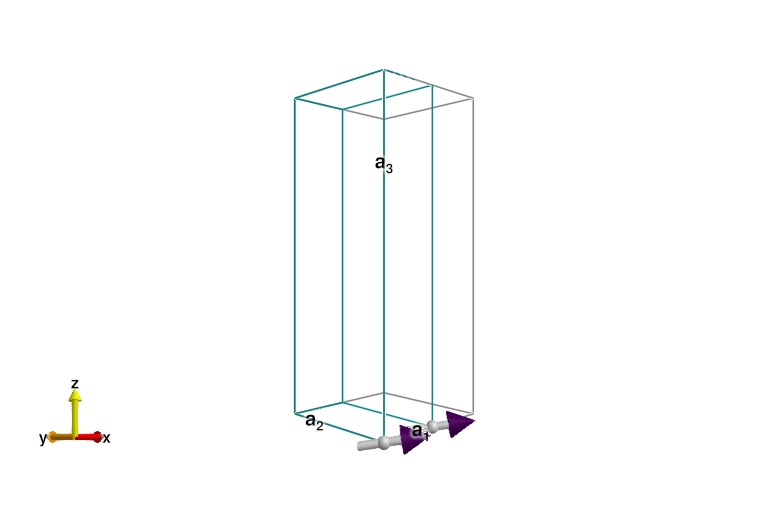

In [3]:
# We also specify the kwarg "dims" which is the size of the supercell. Since we have an AFM, the supercell should be (2,1,1)
dims = (2,1,1)
sys = System(cryst, [1 => Moment(s=1, g=1)], :dipole;dims)
# Now we assign bonds to this system. The labeling mirrors that of the view_crystal function
J = -1.0 # (>0 => AFM)
set_exchange!(sys, J, Bond(1, 1, [1, 0, 0]))
# we randomize the spins and then perform an energy minimization of the 
randomize_spins!(sys)
minimize_energy!(sys)
plot_spins(sys; color=[S[3] for S in sys.dipoles])


# S^αβ(q,w) is a 3x3 matrix with the elements corresponding to α,β ∈ [x,y,z]. We need to specify how we wish to contract this matrix to plot.
# In conventional neutron scattering they measure the component perpendicular to  the momentum transfer. To specify this we use ssf_perp(sys). 
# The trace is specificed by ssf_trace

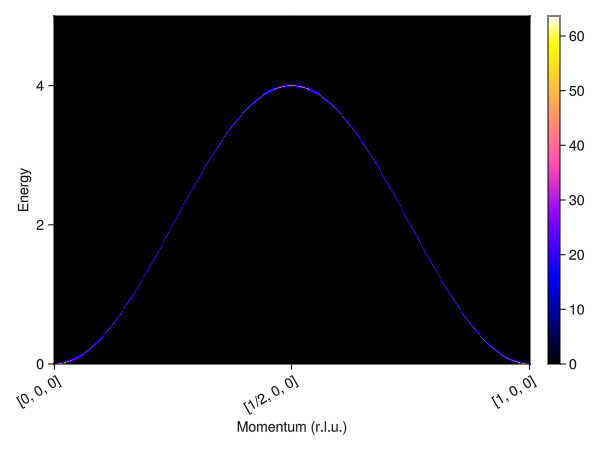

In [4]:
measure = ssf_trace(sys; )
#measure = ssf_custom((q, ssf) -> real(ssf[1,1]), sys)
swt = SpinWaveTheory(sys; measure) # constructs an object to do LSWT on 

kernel = lorentzian(fwhm=0.01) # chooses a kernel. In the Lehmann Representation of the dynamical susceptibilty we saw a delta function. This here approximates this with a finite width Lorentzian
# Choose some reciprocal space path. Since it is 1-d only 1 direction makes sense.
qs = [[0, 0, 0], [1/2, 0, 0], [1 0 0]]
path = q_space_path(cryst, qs, 500)
energies = range(0, 5, 4000) # choose energy range
# calculate ∑ⱼSʲʲ(q,ω) and plot.
res1FM = intensities(swt, path; energies, kernel)
plot_intensities(res1FM;) # This is structure factor (Q=x,ω=y)

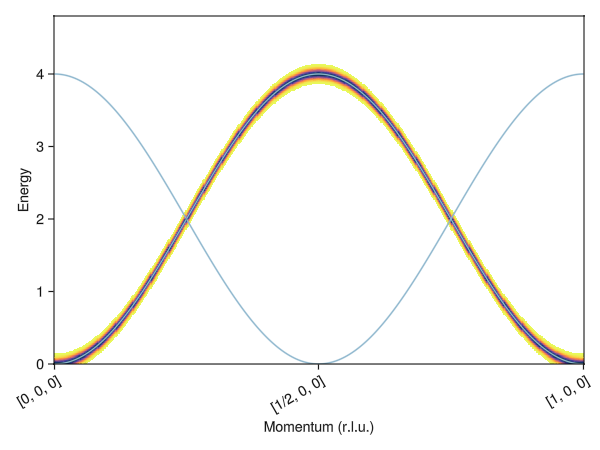

In [5]:
resFM = intensities_bands(swt, path)
plot_intensities(resFM; )

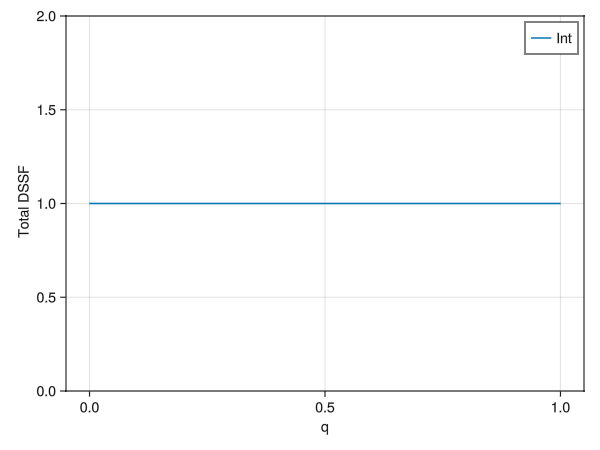

In [13]:
ys1 = resFM.data[1,:]+ resFM.data[2,:] # Creates an array of [ΣS(Q,ω)=S(ω)] so each index is different ω?
ys2 = resFM.disp[1,:] + resFM.disp[2,:]
xs = [q[1] for q in path.qs]
fig = lines(xs, ys1; axis=(xlabel="q", ylabel="Total DSSF"), label="Int")
ylims!(0,2)
axislegend()
fig

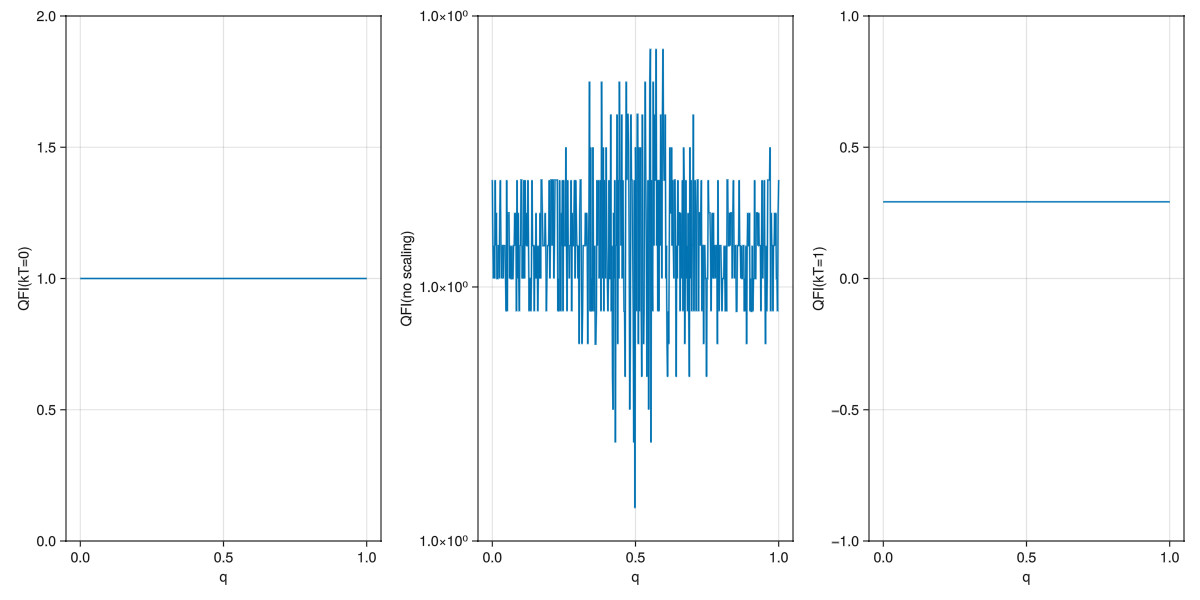

In [8]:
#1/S^2 out of the front is just 1 as S=1 (this is different S to S from DSSF)
#kT = 0.7125
kT = 0
kT1 = 4
xs = [q[1] for q in path.qs]
ys1 = resFM.data[1,:]+ resFM.data[2,:]
ys2 = resFM.disp[1,:] + resFM.disp[2,:]
hw_part = tanh.(ys2 ./(2kT)).*(1 .- exp.(-ys2 ./(kT)))
hw_part1 = tanh.(ys2 ./(2kT1)).*(1 .- exp.(-ys2 ./(kT1)))
QFI = ys1 .*hw_part
QFI1 = ys1 .*hw_part1


begin
    fig = Figure(size=(1200,600))
    ax1FM = Axis(fig[1,1],xlabel="q",ylabel="QFI(kT=0)")
    ax2FM = Axis(fig[1,2],xlabel="q",ylabel="QFI(no scaling)")
    ax3FM = Axis(fig[1,3],xlabel="q",ylabel="QFI(kT=1)")
    lines!(ax1FM,xs,QFI;label="FM")
    lines!(ax2FM,xs,QFI; label="FM(no scaling)")
    lines!(ax3FM,xs,QFI1; label="FM(kT=1)")
    ylims!(ax3FM,-1,1)
    ylims!(ax1FM,0,2)
    fig
end

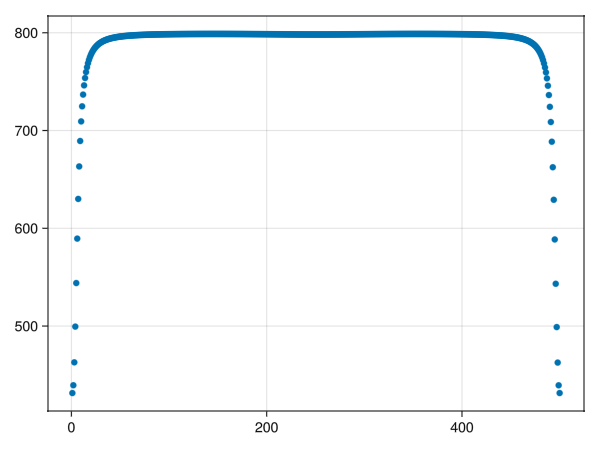

In [30]:
plot([sum(res1FM.data[:,i]) for i ∈ range(1,size(res1FM.data[1,:],1))])

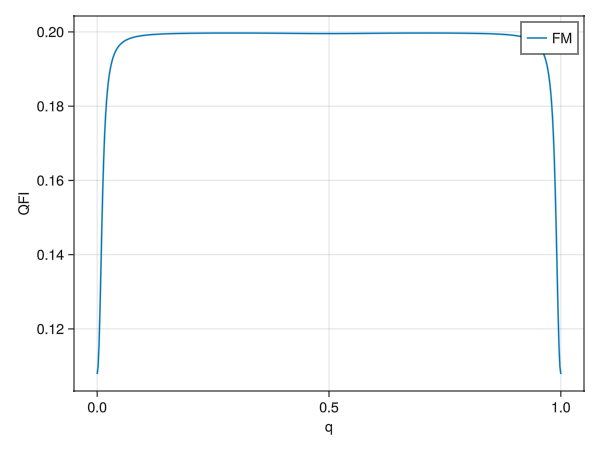

In [9]:
kT = 0
xs = [q[1] for q in path.qs]

#using Integrals
#f(x, p) = tanh(x/kT)*(1-exp(-x/kT))
#p = 1
#domain = res1.energies # (lb, ub)
#prob = IntegralProblem(f, domain)
#sol = solve(prob, QuadGKJL())
#QFI = sum(resFM.data[:,xs])/size(resFM.data,1)
#S = sum(res1.data, dims=1)
#QFI12 = vec(S .*sol)


QFI1 = []
for i in range(1, 500)
    append!(QFI1, sum(res1FM.data[:,i]) ./size(res1FM.data,1))
end

fig = lines(xs, QFI1; axis=(xlabel="q", ylabel="QFI"), label = "FM")
axislegend()
fig
#plot(res1FM.data[:,200])
#res1FM.data
#energy rangs is the same for all q so tanh and exp parts are just constant so Temp doesn't affect??????